In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [4]:
# Create synthetic dataset
np.random.seed(42)

n=500

age = np.random.randint(25, 80, size=n)
systolic_bp = np.random.normal(130, 15, size=n).astype(int)
diastolic_bp = np.random.normal(80, 10, size=n).astype(int)
cholesterol = np.random.normal(200, 40, size=n).astype(int)
bmi = np.random.normal(27, 4, size=n)
smoker = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
physically_active = np.random.choice([0, 1], size=n, p=[0.5, 0.5])

# Create the target variable
disease_prob = (0.03 * age +
                0.02 * (systolic_bp -120) +
                0.015 * (cholesterol - 180) +
                5 * smoker - 3 * physically_active + np.random.normal(0, 3, size=n))
prob = 1 / (1 + np.exp(-0.1*(disease_prob - 10)))

# Binary target
target = (prob > 0.5).astype(int)

# Combine it into a dataframe
df = pd.DataFrame({
'age': age,
'systolic_bp': systolic_bp,
'diastolic_bp': diastolic_bp,
'cholesterol': cholesterol,
'bmi': bmi,
'smoker': smoker,
'physically_active': physically_active,
'target': target
})
df.sample(5)

,age,systolic_bp,diastolic_bp,cholesterol,bmi,smoker,physically_active,target
416,47,137,102,280,32.881283,0,1,0
249,43,134,76,223,23.528000,1,1,0
274,30,153,77,201,25.883566,0,1,0
141,68,120,78,182,27.177038,1,1,0
345,70,106,60,267,21.695620,1,1,0


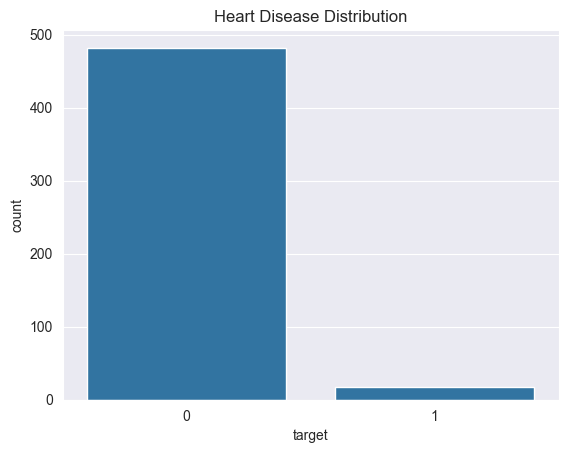

In [5]:
# Visualize the data - This checks class balance
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.show()

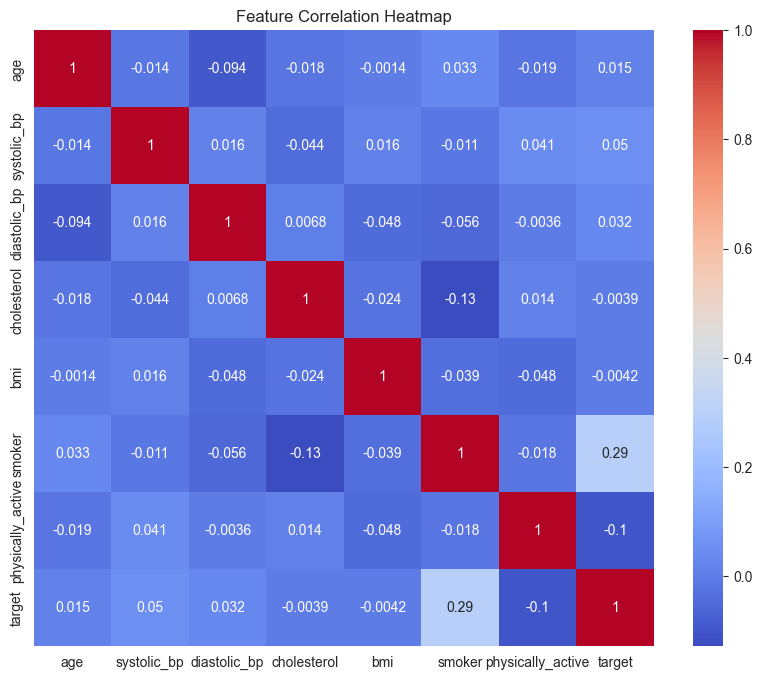

In [6]:
# df.corr() calculates the correlation matrix between all the numeric features in the dataset
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Train Random Forest
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Evaluate
y_pred = rf.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred), end="\n\n")
print("-----Classification Report-----\n\n", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

-----Classification Report-----

               precision    recall  f1-score   support

           0       0.97      1.00      0.98       145
           1       0.00      0.00      0.00         5

    accuracy                           0.97       150
   macro avg       0.48      0.50      0.49       150
weighted avg       0.93      0.97      0.95       150



D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


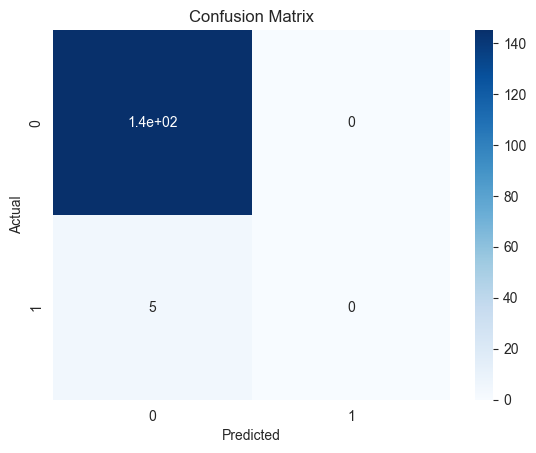

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Now the model has learned how each feature contributes to predicting the target. The attribute .feature_importances_ is a numpy array that stores a number for each feature in the dataset

# You can drop features with low importance to simplify the model
importances = rf.feature_importances_
importances

array([0.10691178, 0.179753  , 0.15884256, 0.20478807, 0.24217932,
       0.08401447, 0.02351081])

In [12]:
indices = np.argsort(importances)[::-1]
indices

array([4, 3, 1, 2, 0, 5, 6])

C:\Users\muham\AppData\Local\Temp\ipykernel_25184\84659925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


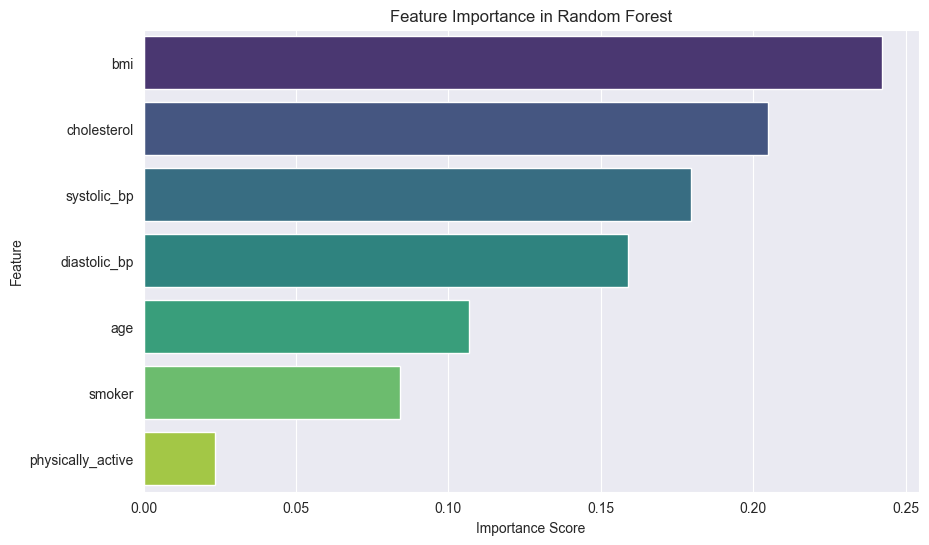

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Feature Importance in Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()